# $\alpha$ ablation study figures

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks_causal_cactus":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="2,3"

%load_ext autoreload
%autoreload 2

In [2]:
from src.DataReaders import *
from src.address import *
from src.modelGen import *
from src.utils import cf_eval, cleanup_gpu
from models import CF_CausalCondLatentCF, CF_LatentCFpp, CF_PrototypeCF
from models import CF_CondLatentCF # Note: get the vanilla CondLatentCF
import numpy as np
import random 
from tensorflow import random as tf_random
import matplotlib.pyplot as plt
import os
import pandas as pd


2026-06-15 11:34:02.987737: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
SEED = 23

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf_random.set_seed(SEED)


CF_METHODS = {  
    "LatentCFpp": CF_LatentCFpp,
    "Prototype": CF_PrototypeCF,
    "CausalCACTUS": CF_CausalCondLatentCF,
    "CACTUS": CF_CondLatentCF
}

## Exp Set-up

In [13]:
# Importing raw data

PATH = "../results/results_ablation1_full.csv"
MODELS_NAMES = ["CausalCACTUS (Min.)", "CausalCACTUS (Mod.)", "Original CACTUS"]
ALPHAS = [] 
METRICS_NAMES = ["validity","lof_context","compactness"]
METRICS_LABELS = ["Validity","Context-LOF","Compactness"]
DATASETS_LABELS = ["Credit","Adult","Law","German","HELOC"]

In [5]:
ablation_data = pd.read_csv(PATH)
ALPHAS = ablation_data.Alpha.unique().tolist()

print(ablation_data.shape) # 225, 5 -> 5 alpahs x 5 trials x 9 metrics = 225 rows
print(ablation_data)


(500, 10)
     Dataset Prior  Alpha      CFMethod  BootstrapID  validity  lof_context  \
0    1credit   min   0.01        CACTUS            0      0.08     1.204757   
1    1credit   min   0.01        CACTUS            1      0.12     1.112646   
2    1credit   min   0.01        CACTUS            2      0.12     1.162632   
3    1credit   min   0.01        CACTUS            3      0.10     1.107575   
4    1credit   min   0.01        CACTUS            4      0.08     1.158267   
..       ...   ...    ...           ...          ...       ...          ...   
495   5heloc   mod   0.99  CausalCACTUS            0      0.72     1.274746   
496   5heloc   mod   0.99  CausalCACTUS            1      0.76     1.146887   
497   5heloc   mod   0.99  CausalCACTUS            2      0.82     1.086118   
498   5heloc   mod   0.99  CausalCACTUS            3      0.80     1.150632   
499   5heloc   mod   0.99  CausalCACTUS            4      0.80     1.194448   

     compactness  n_proximity  causal_com

In [6]:

# Group by of different alphas
ablation_data_mean = ablation_data.groupby(["Alpha","Prior","Dataset","CFMethod"])[METRICS_NAMES].mean()
ablation_data_std = ablation_data.groupby(["Alpha","Prior","Dataset","CFMethod"])[METRICS_NAMES].std()
ablation_data_mean.reset_index()
    

,Alpha,Prior,Dataset,CFMethod,validity,lof_context,compactness
0,0.01,min,1credit,CACTUS,0.100,1.149175,0.590000
1,0.01,min,1credit,CausalCACTUS,0.272,1.142046,0.773000
2,0.01,min,2adult,CACTUS,0.088,1.064404,0.646857
3,0.01,min,2adult,CausalCACTUS,0.192,1.067554,0.855429
4,0.01,min,3law,CACTUS,0.184,1.046076,0.513333
...,...,...,...,...,...,...,...
95,0.99,mod,3law,CausalCACTUS,0.752,1.043135,0.323556
96,0.99,mod,4german,CACTUS,0.816,1.038586,0.016667
97,0.99,mod,4german,CausalCACTUS,0.828,1.031424,0.186000
98,0.99,mod,5heloc,CACTUS,0.692,1.179382,0.048667


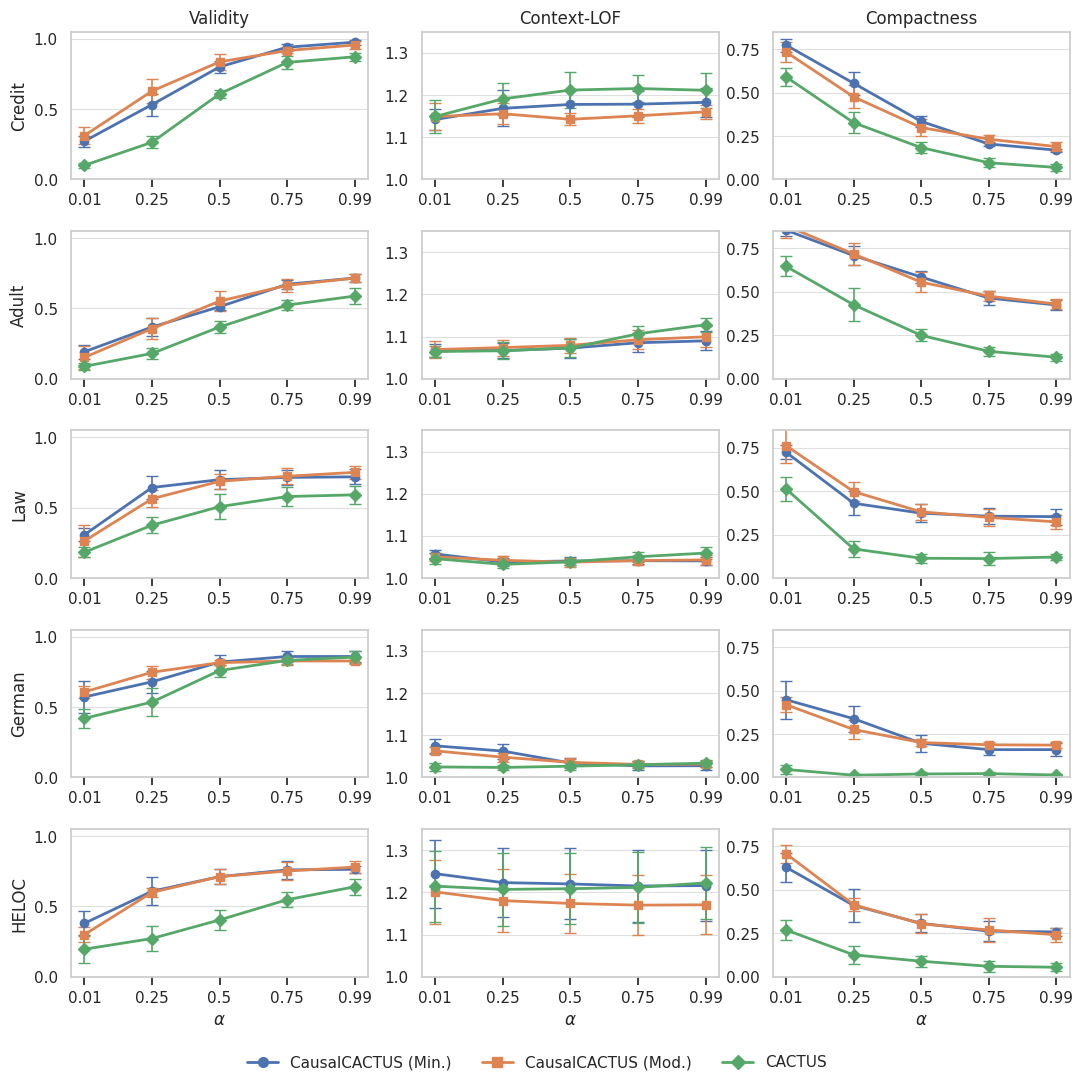

In [20]:
# Figure from aggregated bootstrap means/stds across datasets
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from types import SimpleNamespace

sns.set_theme(style="whitegrid")

metrics = [metric for metric in METRICS_NAMES if metric in ablation_data_mean.columns]
if isinstance(METRICS_LABELS, dict):
    metric_labels = {metric: METRICS_LABELS.get(metric, metric) for metric in metrics}
else:
    metric_labels = {
        metric: METRICS_LABELS[i] if i < len(METRICS_LABELS) else metric
        for i, metric in enumerate(metrics)
    }

id_cols = ["Alpha", "Prior", "Dataset", "CFMethod"]
mean_long = ablation_data_mean.reset_index().melt(
    id_vars=id_cols,
    value_vars=metrics,
    var_name="metric",
    value_name="mean",
)
std_long = ablation_data_std.reset_index().melt(
    id_vars=id_cols,
    value_vars=metrics,
    var_name="metric",
    value_name="std",
)

plot_df = mean_long.merge(std_long, on=id_cols + ["metric"], how="left")
plot_df["metric_label"] = plot_df["metric"].map(metric_labels)
plot_df["Alpha"] = plot_df["Alpha"].astype(float)

prior_order = [prior for prior in ["min", "mod"] if prior in set(plot_df["Prior"])]
prior_order += [prior for prior in sorted(plot_df["Prior"].unique()) if prior not in prior_order]

# CACTUS is prior-independent. Keep one copy when the aggregated table contains it for each prior.
cactus_keep_prior = prior_order[0] if prior_order else None
plot_df = plot_df[
    (plot_df["CFMethod"] != "CACTUS") | (plot_df["Prior"] == cactus_keep_prior)
].copy()

def model_label(row):
    if row["CFMethod"] == "CausalCACTUS":
        return f"CausalCACTUS ({row['Prior'].title()}.)"
    return row["CFMethod"]

plot_df["model"] = plot_df.apply(model_label, axis=1)

alpha_order = sorted(plot_df["Alpha"].unique())
alpha_labels = [str(alpha).rstrip("0").rstrip(".") for alpha in alpha_order]
x_positions = np.arange(len(alpha_order))
alpha_to_x = dict(zip(alpha_order, x_positions))

dataset_order = sorted(plot_df["Dataset"].unique())
if isinstance(DATASETS_LABELS, dict):
    dataset_labels = {dataset: DATASETS_LABELS.get(dataset, dataset) for dataset in dataset_order}
else:
    dataset_labels = {
        dataset: DATASETS_LABELS[i] if i < len(DATASETS_LABELS) else dataset
        for i, dataset in enumerate(dataset_order)
    }
plot_df["dataset_label"] = plot_df["Dataset"].map(dataset_labels)
metric_order = [metric_labels[metric] for metric in metrics]
metric_ylim = {
    "Validity": (0, 1.05),
    "Context-LOF": (1, 1.35),
    "Compactness": (0, 0.85),
}
model_order = ["CausalCACTUS (Min.)", "CausalCACTUS (Mod.)", "CACTUS"]
model_order = [model for model in model_order if model in set(plot_df["model"])]

palette = dict(zip(model_order, sns.color_palette(n_colors=len(model_order))))
markers = dict(zip(model_order, ["o", "s", "D", "^"][:len(model_order)]))

fig, axes = plt.subplots(
    nrows=len(dataset_order),
    ncols=len(metric_order),
    figsize=(3.7 * len(metric_order), 2.25 * len(dataset_order)),
    sharex=True,
    squeeze=False,
)

for row_idx, dataset in enumerate(dataset_order):
    for col_idx, metric_label in enumerate(metric_order):
        ax = axes[row_idx, col_idx]
        ax_df = plot_df[
            (plot_df["Dataset"] == dataset) & (plot_df["metric_label"] == metric_label)
        ]

        for model in model_order:
            model_df = ax_df[ax_df["model"] == model].sort_values("Alpha")
            if model_df.empty:
                continue

            ax.errorbar(
                model_df["Alpha"].map(alpha_to_x).to_numpy(),
                model_df["mean"].to_numpy(dtype=float),
                yerr=model_df["std"].to_numpy(dtype=float),
                color=palette[model],
                marker=markers[model],
                linestyle="-",
                linewidth=2,
                markersize=6,
                capsize=4,
                elinewidth=1.2,
                label=model,
            )

        ax.set_facecolor("white")
        ax.grid(True, axis="y", color="#DADADA", linewidth=0.8, alpha=0.85)
        ax.grid(False, axis="x")
        ax.set_axisbelow(True)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(alpha_labels)
        ax.tick_params(axis="x", labelbottom=True, bottom=True)
        ax.set_xlabel(r"$\alpha$" if row_idx == len(dataset_order) - 1 else "")
        ax.set_ylabel(dataset_labels.get(dataset, dataset) if col_idx == 0 else "")
        if metric_label in metric_ylim:
            ax.set_ylim(*metric_ylim[metric_label])
        if row_idx == 0:
            ax.set_title(metric_label)

legend_handles = [
    Line2D(
        [0], [0],
        color=palette[model],
        marker=markers[model],
        linestyle="-",
        linewidth=2,
        markersize=7,
        label=model,
    )
    for model in model_order
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.005),
    ncol=len(model_order),
    frameon=False,
    title=None,
)
fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.1,
    top=0.94,
    wspace=0.18,
    hspace=0.35,
)

ablation_bootstrap_plot_df = plot_df
ablation_bootstrap_fig = fig
g = SimpleNamespace(figure=fig)

plt.show()


In [21]:
g.figure.savefig(
    "../results/figs/ablation_study_fig.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)
